# Credit Score Classification

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.tree import DecisionTreeClassifier
import re

In [70]:
#Read Dataset
df= pd.read_csv('dataset/train.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

/var/folders/g_/wx182l8j3rjdrb5rv53tf7180000gn/T/ipykernel_50181/1022397046.py:2: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv('dataset/train.csv')


In [71]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


## 1. Data Cleaning

In [72]:
df_cleaned = df.copy()
df_cleaned.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [73]:
# Drop the personal information as columns
drop_columns = ['ID','Customer_ID','Month','Name','SSN']
df_cleaned = df_cleaned.drop(drop_columns, axis = 1)
df_cleaned.shape


(100000, 23)

### 1.1 Numerical Data

In [74]:
# The numeric columns: 8
numerical_columns = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
    'Num_Credit_Card', 'Interest_Rate','Delay_from_due_date', 'Num_of_Loan', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly',
    'Monthly_Balance', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries'
]
len(numerical_columns)

16

In [75]:
df_cleaned.select_dtypes('number').columns

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

In [76]:
# format the columns
df_cleaned['Age'] = df_cleaned['Age'].str.replace(r'_', '', regex=True).astype(int)
df_cleaned['Num_of_Loan'] = df_cleaned['Num_of_Loan'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Annual_Income'] = df_cleaned['Annual_Income'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Outstanding_Debt'] = df_cleaned['Outstanding_Debt'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Monthly_Balance'] = df_cleaned['Monthly_Balance'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Num_of_Delayed_Payment'] = df_cleaned['Num_of_Delayed_Payment'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Amount_invested_monthly'] = df_cleaned['Amount_invested_monthly'].str.replace(r'_', '', regex=True).astype(float)
df_cleaned['Changed_Credit_Limit'] = df_cleaned['Changed_Credit_Limit'].str.replace(r'_', '', regex=True).replace('', np.nan).astype(float)

In [77]:
# Convert Data Types: Ensure numeric format
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    pd.to_numeric, errors='coerce'
)

# Drop all rows of age less than 0
df_cleaned = df_cleaned[(df_cleaned['Age'] >= 0) & (df_cleaned['Age'] <= 100)]

# Drop all the num of loans less than 0
df_cleaned = df_cleaned[df_cleaned['Num_of_Loan']>=0]

# Reset all negative Num_Bank_Accounts to 0
df_cleaned.loc[df_cleaned['Num_Bank_Accounts']<0,'Num_Bank_Accounts'] = 0

# Reset all negative Num_of_Delayed_Payment to 0
df_cleaned.loc[df_cleaned['Num_of_Delayed_Payment']<0,'Num_of_Delayed_Payment'] = 0

#Convert Credit_History_Age to a float number of days
def age2days(text, years=0, months=0):
    # Validate and handle empty or invalid input
    if not text or not isinstance(text, str):
        return 0  # Return 0 if text is empty or invalid
    
    days_in_year = 365.25
    days_in_month = 30.44

    years_match = re.search(r'(\d+)\s*Years?', text, re.IGNORECASE)
    months_match = re.search(r'(\d+)\s*Months?', text, re.IGNORECASE)

    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0

    return int((years * days_in_year) + (months * days_in_month))

df_cleaned['Credit_History_Age'] = df_cleaned['Credit_History_Age'].apply(age2days)

# Handle Missing Values: Impute with median
df_cleaned[numerical_columns] = df_cleaned[numerical_columns].apply(
    lambda x: x.fillna(x.median())
)


# Remove Outliers: Clip to 1st and 99th percentile
for column in numerical_columns:
    lower = df_cleaned[column].quantile(0.01)
    upper = df_cleaned[column].quantile(0.99)
    df_cleaned[column] = df_cleaned[column].clip(lower, upper)

### 1.2 Categorical Data

In [78]:
#Replace the '_______' value in the Occupation field with Other
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('_______', 'Other')

#Correct Typo
df_cleaned['Payment_of_Min_Amount'] = df_cleaned['Payment_of_Min_Amount'].str.replace('NM', 'No')

#Drop Typo
df_cleaned = df_cleaned[df_cleaned['Payment_Behaviour']!='!@9#%8']

In [79]:
# hasn't done processing yet, drop for now

df_cleaned.drop(columns=['Type_of_Loan'],inplace=True)
df_cleaned.drop(columns=['Credit_Mix'],inplace=True)

## 2. Data Visualization

/var/folders/g_/wx182l8j3rjdrb5rv53tf7180000gn/T/ipykernel_50181/257259202.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df_cleaned['Credit_Score'],palette="mako");
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.ge

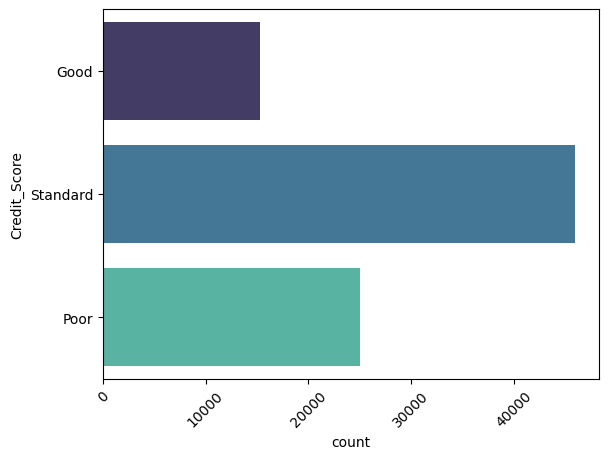

In [ ]:
sns.countplot(df_cleaned['Credit_Score'],palette="mako")
plt.xticks(rotation=45)

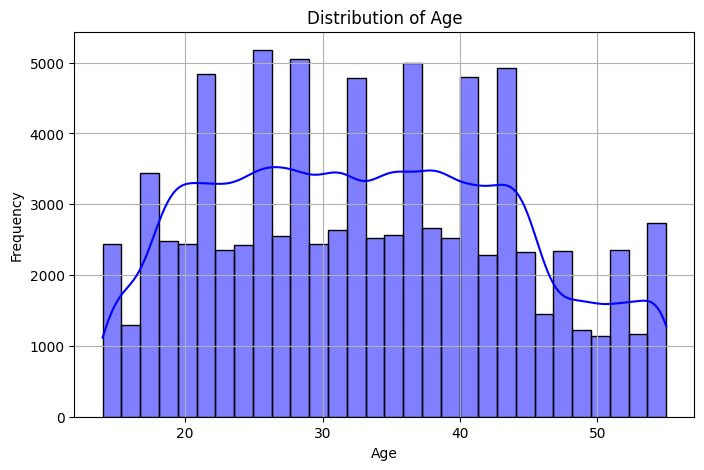

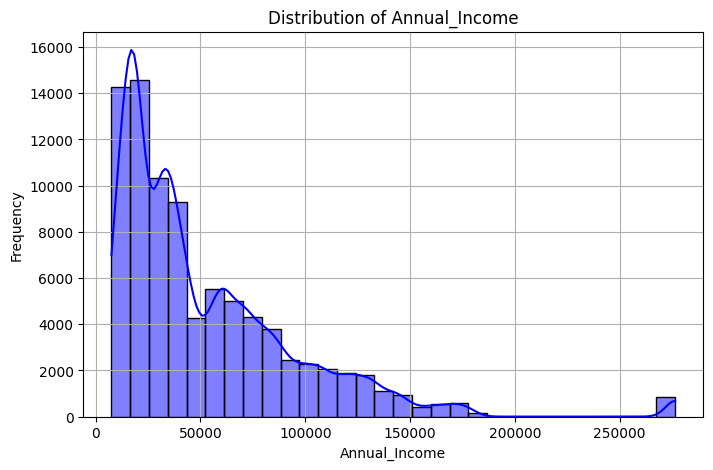

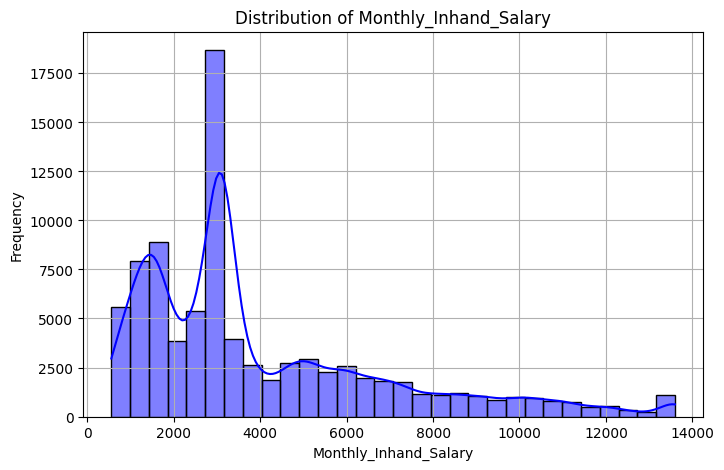

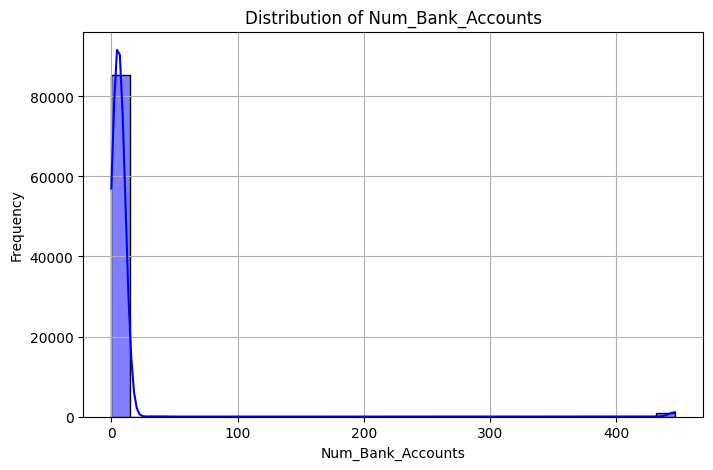

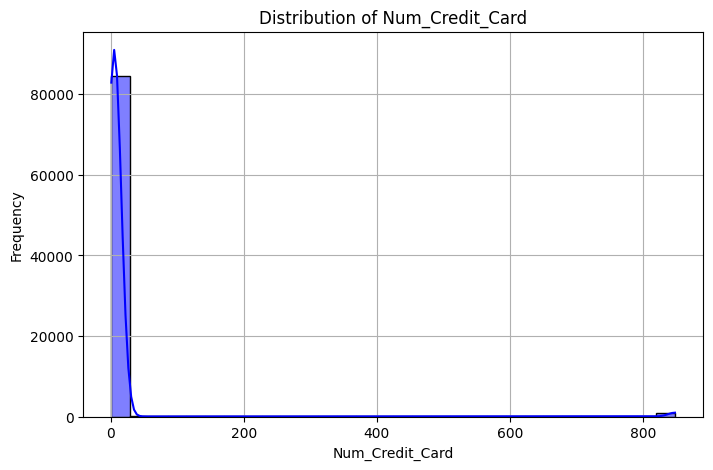

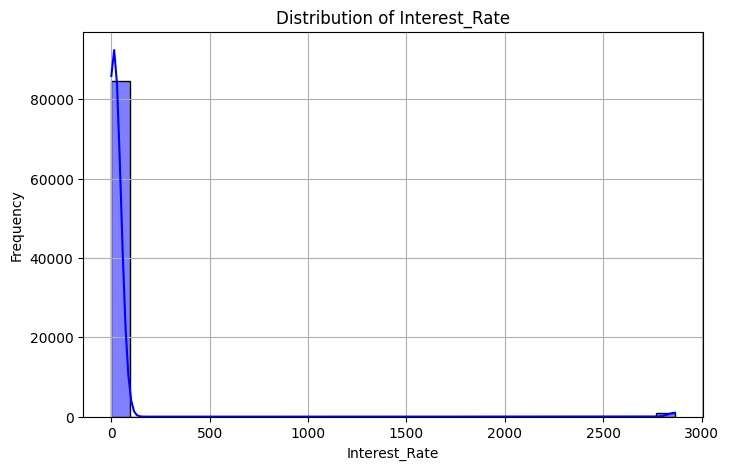

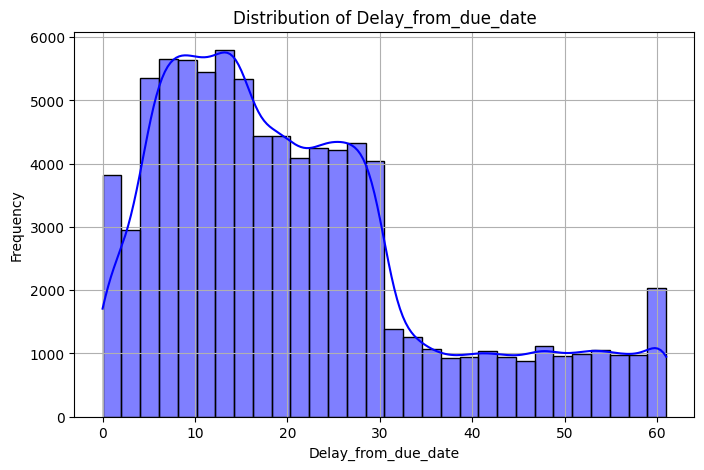

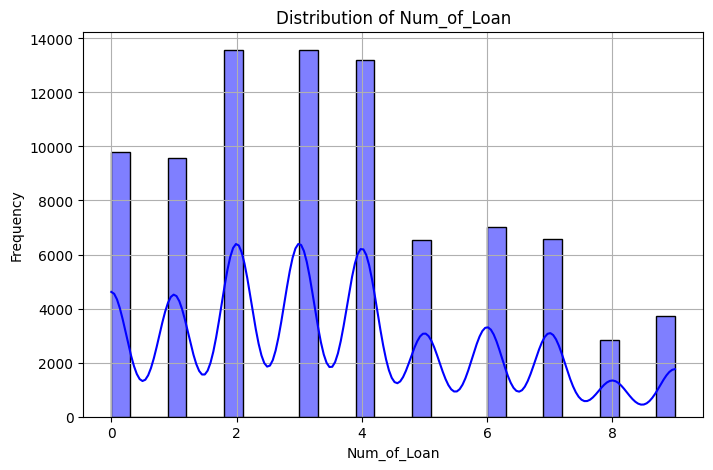

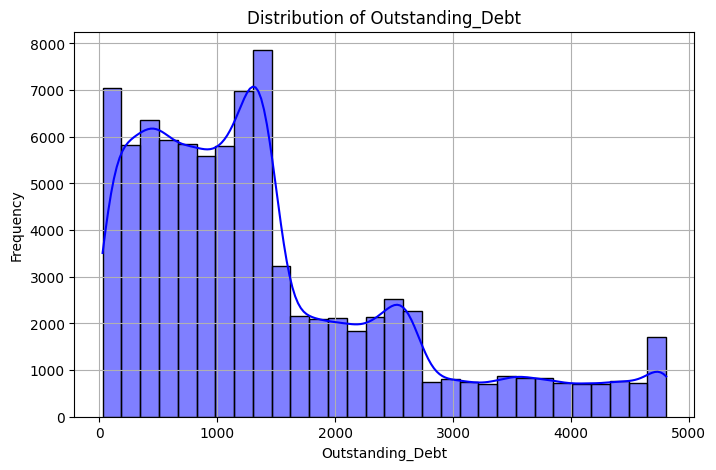

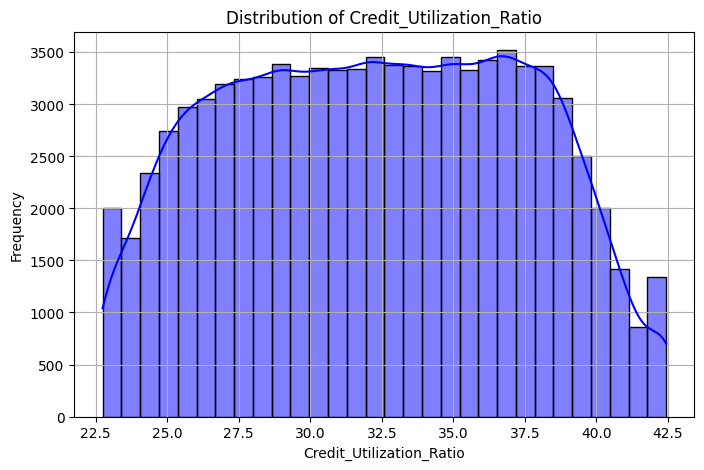

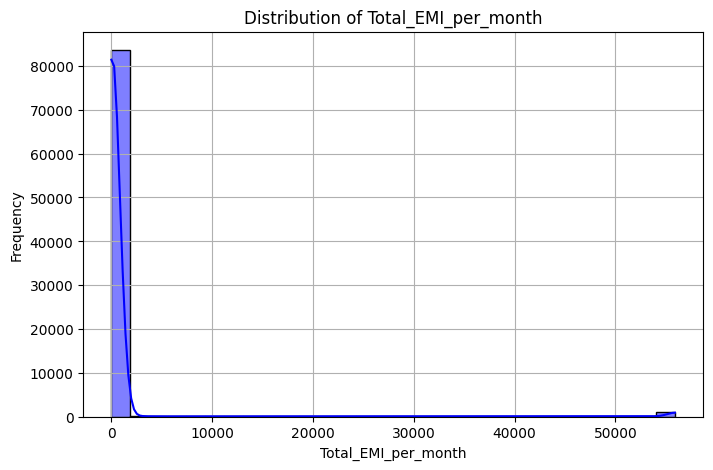

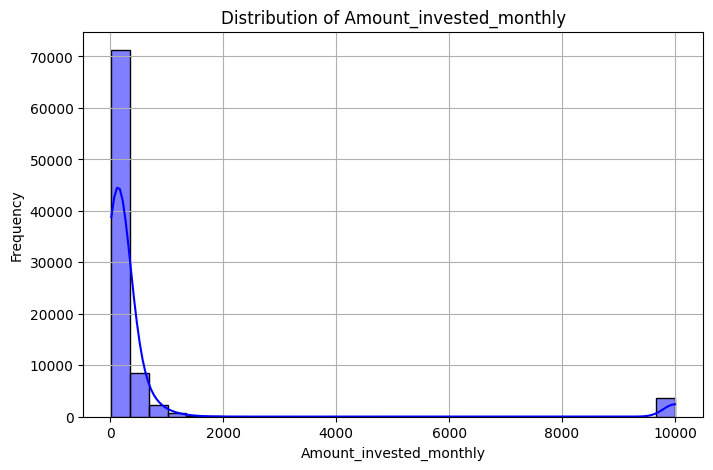

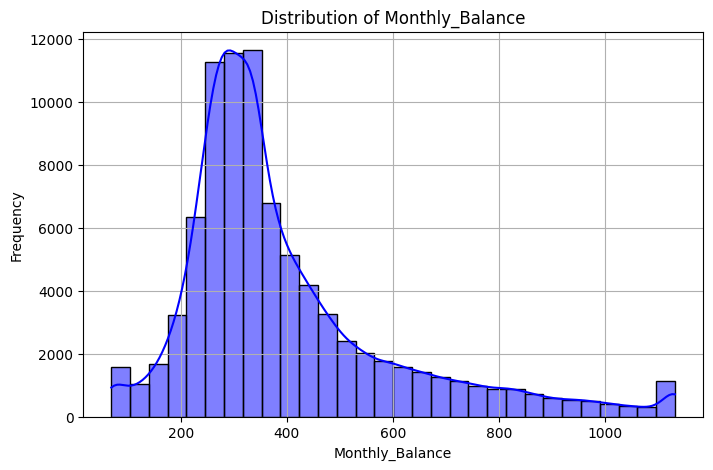

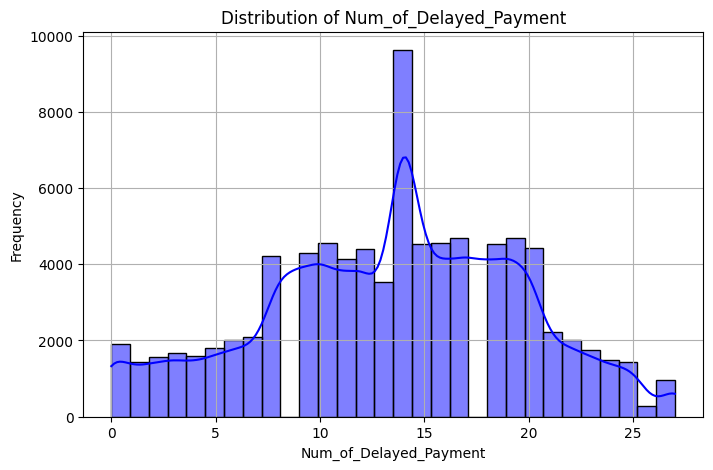

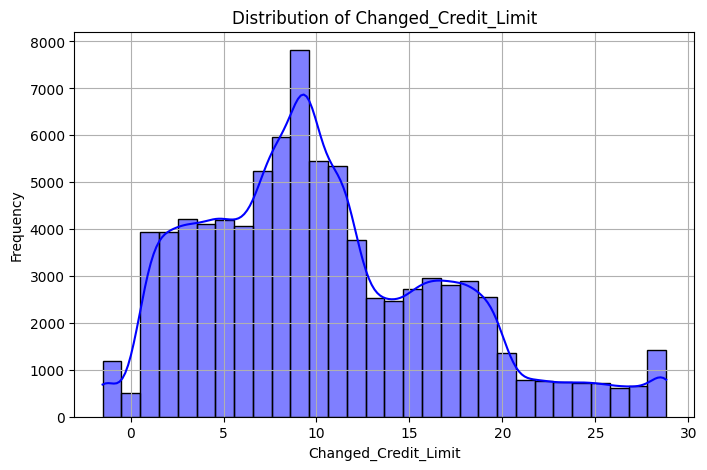

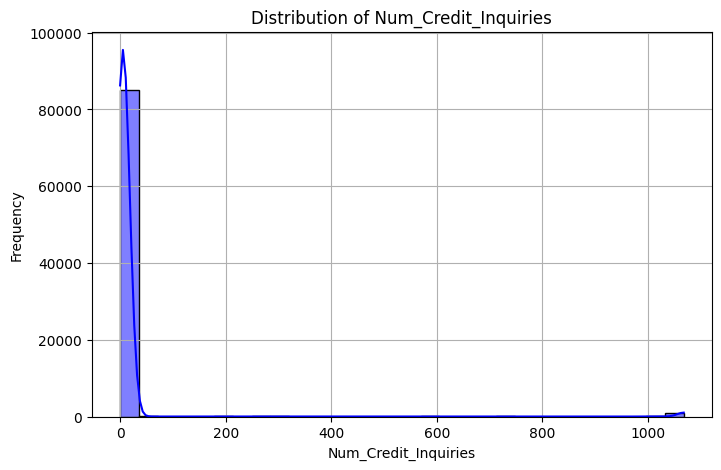

In [80]:
# Set up visualizations
for numerical_column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[numerical_column], kde=True, bins=30, color='blue', edgecolor='black')
    plt.title(f'Distribution of {numerical_column}')
    plt.xlabel(numerical_column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()


## 3. Feature Engineering

### 3.1 Encoding

In [81]:
df_final = df_cleaned.copy()
df_final.head().T

,0,1,3,4,6
Age,23,23,23,23,23
Occupation,Scientist,Scientist,Scientist,Scientist,Scientist
Annual_Income,19114.12,19114.12,19114.12,19114.12,19114.12
Monthly_Inhand_Salary,1824.843333,3095.905,3095.905,1824.843333,1824.843333
Num_Bank_Accounts,3.0,3.0,3.0,3.0,3.0
Num_Credit_Card,4.0,4.0,4.0,4.0,4.0
Interest_Rate,3.0,3.0,3.0,3.0,3.0
Num_of_Loan,4.0,4.0,4.0,4.0,4.0
Delay_from_due_date,3,0,5,6,3
Num_of_Delayed_Payment,7.0,14.0,4.0,14.0,8.0


In [82]:
df_final['Payment_of_Min_Amount'] = pd.get_dummies(df_final['Payment_of_Min_Amount'], columns=['Payment_of_Min_Amount'],prefix='Payment_of_Min_Amount',dtype=float,drop_first=True)

one_hot_encoding_columns = ['Occupation', 'Payment_Behaviour']
one_hot_encoded_columns = pd.get_dummies(df_final[one_hot_encoding_columns], dtype=float)
df_final = df_final.drop(columns=one_hot_encoding_columns).join(one_hot_encoded_columns)

In [83]:
X = df_final.drop(columns=['Credit_Score'])
X.head().T

,0,1,3,4,6
Age,23.000000,23.000000,23.000000,23.000000,23.000000
Annual_Income,19114.120000,19114.120000,19114.120000,19114.120000,19114.120000
Monthly_Inhand_Salary,1824.843333,3095.905000,3095.905000,1824.843333,1824.843333
Num_Bank_Accounts,3.000000,3.000000,3.000000,3.000000,3.000000
Num_Credit_Card,4.000000,4.000000,4.000000,4.000000,4.000000
Interest_Rate,3.000000,3.000000,3.000000,3.000000,3.000000
Num_of_Loan,4.000000,4.000000,4.000000,4.000000,4.000000
Delay_from_due_date,3.000000,0.000000,5.000000,6.000000,3.000000
Num_of_Delayed_Payment,7.000000,14.000000,4.000000,14.000000,8.000000
Changed_Credit_Limit,11.270000,11.270000,6.270000,11.270000,11.270000


In [84]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df_final['Credit_Score'])
y

array([0, 0, 0, ..., 1, 1, 2])

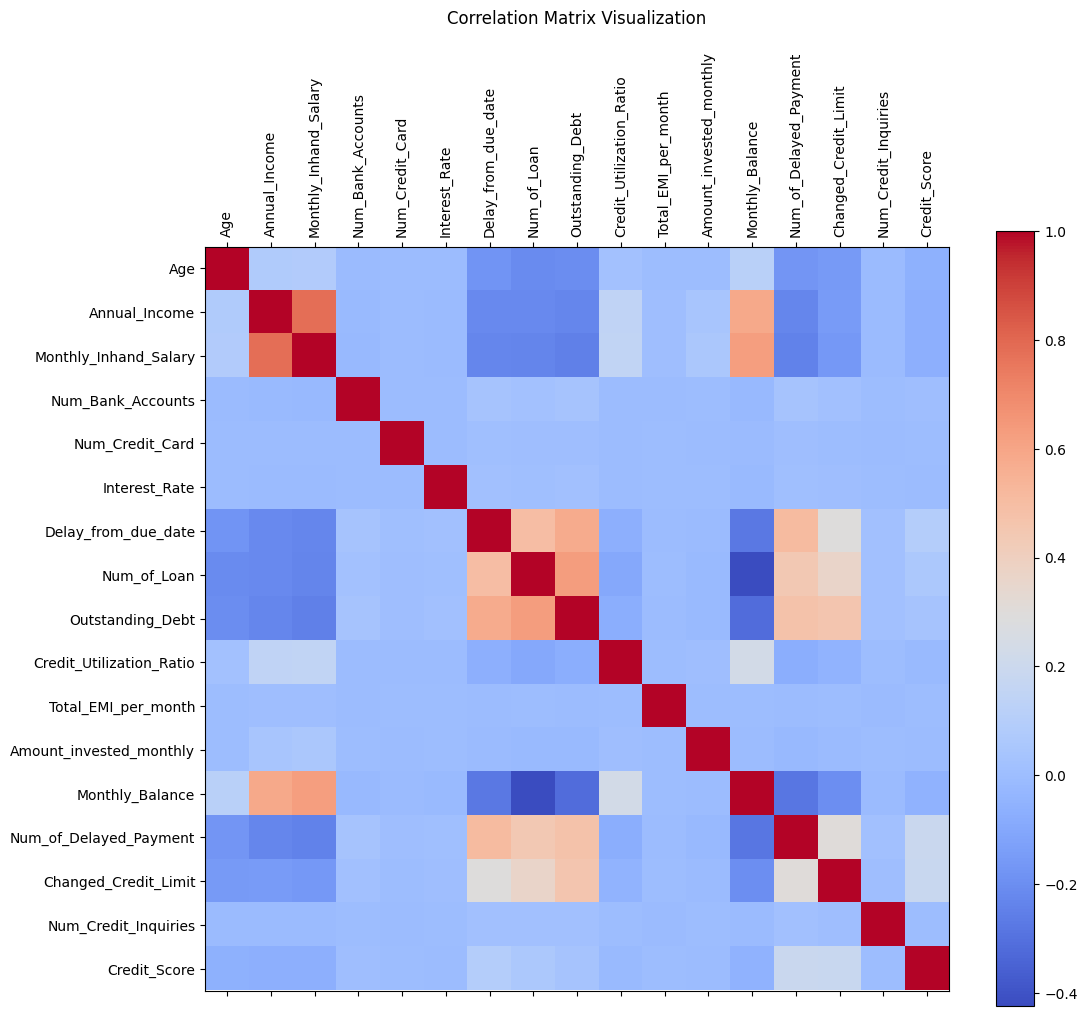

In [85]:
df_final['Credit_Score'] = label_encoder.fit_transform(df_final['Credit_Score'])
correlation_matrix = df_final[numerical_columns+['Credit_Score']].corr()


# Plotting the correlation matrix
plt.figure(figsize=(12, 10))
plt.matshow(correlation_matrix, fignum=1, cmap='coolwarm')

# Adding colorbar and labels
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Adding title
plt.title("Correlation Matrix Visualization", pad=20)
plt.show()


## 4. Machine Learning

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print(mse,acc)

0.8647178002894356 0.6071201157742402


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}",mse)

Accuracy: 0.70 0.6727062228654125
